In [1]:
#Create custom least squares regression method
import numpy as np
import matplotlib.pyplot as plt
def lst_sqr(X, Y):
    n = len(X)
    sum_x = sum(X)
    sum_y = sum(Y)
    sum_xx = sum(X**2)
    sum_xy = sum(X * Y)
    
    m = (n * sum_xy - sum_x * sum_y)/(n * sum_xx - (sum_x ** 2))
    c = (sum_y - m * sum_x)/n
    return m, c

Slope (own): -0.10950455525946161, Intercept (own): 6.1511250592274465
Slope (default): -0.10950455525946086, Intercept (default): 6.151125059227439


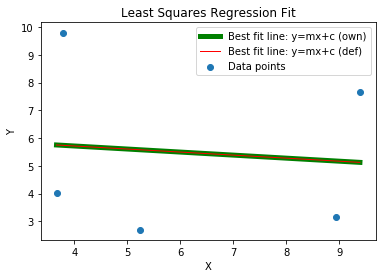

In [2]:
#Create random vectors of X and Y and find least squares regression using own method and built in
X = np.sort(np.random.uniform(1, 10, 5))
Y = np.random.uniform(1, 10, 5)
A = np.vstack([X, np.ones(len(X))]).T
m_own, c_own = lst_sqr(X, Y)
m_def, c_def = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope (own): {m_own}, Intercept (own): {c_own}")
print(f"Slope (default): {m_def}, Intercept (default): {c_def}")

plt.scatter(X, Y, label='Data points')
plt.plot(X, m_own*X + c_own, '-g', label='Best fit line: y=mx+c (own)', linewidth=5.0)
plt.plot(X, m_def*X + c_def, '-r', label='Best fit line: y=mx+c (def)', linewidth=1.0)
plt.title('Least Squares Regression Fit')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

Slope (own): 3.6184718053441527, Intercept (own): 2.419555379534014
Slope (default): 3.6184718053441522, Intercept (default): 2.4195553795340117


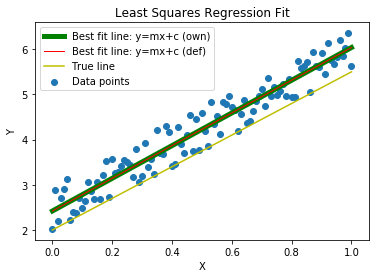

Residuals: [-0.40089089  0.43371973 -0.28783228  0.16999742  0.34455246  0.52112051
 -0.41849056 -0.28718472 -0.34384018 -0.03903657 -0.29782261 -0.1719294
  0.20107564 -0.02488531 -0.23302605  0.0964685  -0.30909155  0.19196834
  0.45862449 -0.38235842  0.4373792   0.07708453  0.06507     0.15567492
  0.26595653  0.18278726  0.08794383 -0.22091764  0.35118979 -0.41836256
 -0.30244494  0.39244533 -0.19272811 -0.03371748 -0.41213311  0.52840551
 -0.02899641 -0.08850365  0.5146588   0.3314576  -0.45629319 -0.43458655
  0.34258766 -0.07115164 -0.30672538  0.05994423  0.4602246  -0.37198018
  0.29294438 -0.42830417  0.36087999 -0.06534451 -0.45316315  0.49663034
 -0.02889638  0.10902912 -0.31974126  0.34242387  0.27699236  0.41029643
  0.1316234   0.03858481 -0.46342887 -0.12376433  0.13942373 -0.41130829
 -0.3986394  -0.20897542 -0.02429216  0.05470068  0.16714959 -0.24303611
  0.32805657 -0.09700977  0.05671978 -0.13753214 -0.10393777  0.02997147
 -0.2738804   0.05800439 -0.37435686 -0.4

In [5]:
#Create array for x and calculate y values including random number, run least squares regression with both methods
true_m = 3.5
true_b = 2
X = np.linspace(0, 1, 101)
noise = np.random.rand(len(X))
Y = (true_m*X + true_b + noise)
A = np.vstack([X, np.ones(len(X))]).T
m_own, c_own = lst_sqr(X, Y)
m_def, c_def = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope (own): {m_own}, Intercept (own): {c_own}")
print(f"Slope (default): {m_def}, Intercept (default): {c_def}")

#Plot least squares regression line for own and default method, as well as the true line
plt.scatter(X, Y, label='Data points')
plt.plot(X, m_own*X + c_own, '-g', label='Best fit line: y=mx+c (own)', linewidth=5.0)
plt.plot(X, m_def*X + c_def, '-r', label='Best fit line: y=mx+c (def)', linewidth=1.0)
plt.plot(X, true_m*X + true_b, '-y', label='True line')
plt.title('Least Squares Regression Fit')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

#Find the residuals of each data point, find largest and smallest residual, print
predicted_y = m_own*X + c_own
residuals = Y - predicted_y
res_max = np.argmax(np.abs(residuals))
res_min = np.argmin(np.abs(residuals))
print(f'Residuals: {residuals}')
print(f'Largest Residual: {residuals[res_max]} at X={res_max * 0.01}')
print(f'Smallest Residual: {residuals[res_min]} at X={res_min * 0.01}')